In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
import torch
import torch.nn as nn   
import torch.optim as optim

from torch.optim import SGD

from torch.utils.data import DataLoader, TensorDataset

Input and target data:

Masking the wavelength grid

In [3]:
final_wave = 3536. + np.arange(4306) * 0.9
original_wave = 3500. + np.arange(4367) * 0.9

In [4]:
low_idx = np.argmin(abs(original_wave - final_wave[0]))
high_idx = np.argmin(abs(original_wave - final_wave[-1]))

In [5]:
preprocessed_flux = np.load("../preprocessing/cflib_data.npz", allow_pickle= True)["flux"]

input_flux = []

for i in range(len(preprocessed_flux)):
    input_flux.append(preprocessed_flux[i][low_idx : high_idx + 1])
    
input_flux = np.array(input_flux)

# input_flux = np.load("../preprocessing/preprocess_cflib_vyom.npy")   # input of vyom preprocessed data

target_flux = np.load("rf_interpolated_fluxes.npy")

print(len(target_flux[0]))  # checking the length of the interpolated flux arrays
print(input_flux)
print(target_flux)


4306
[[1.1825487646914092 1.1841432511841439 1.1860783470682998 ...
  0.4124035574007773 0.4105880111693166 0.4107658742488486]
 [0.05012359158249259 0.05087644314420091 0.05242872825483944 ...
  1.470013205194036 1.4559561793877915 1.4632705648224837]
 [0.2362234472559823 0.23218703652067837 0.23380249477842624 ...
  0.7866333409396982 0.7716400516481633 0.7752994451876409]
 ...
 [0.6531245140554456 0.6494315947886485 0.6536496646603588 ...
  9.85354519046036e-05 9.85354519046036e-05 9.85354519046036e-05]
 [0.40733122403375077 0.38788939127494076 0.39513174101918763 ...
  9.190256391646997e-05 9.190256391646997e-05 9.190256391646997e-05]
 [0.6186189577056762 0.622308238396077 0.6300363299913472 ...
  0.6388013675444142 0.6380960935140043 0.6365599939693225]]
[[1.18601767 1.22942634 1.17626099 ... 0.42062923 0.42171141 0.42278666]
 [0.09260631 0.10392712 0.1085579  ... 1.89134097 1.89760813 1.91798774]
 [0.12836964 0.1376427  0.13979537 ... 0.82752983 0.81743293 0.82009242]
 ...
 [0.78

Checking for the order of the flux data of stars

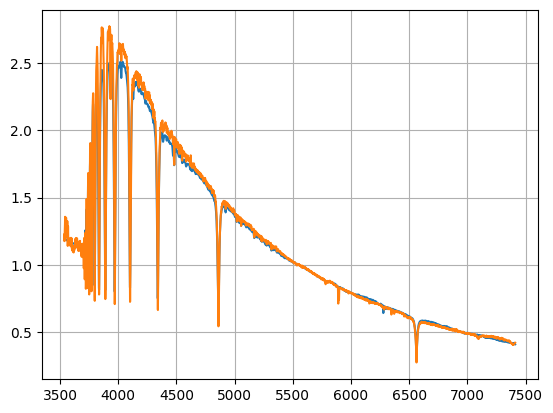

In [6]:
plt.plot(final_wave,input_flux[0])
plt.plot(final_wave,target_flux[0])
plt.grid()

In [7]:
input_flux = np.array(input_flux, dtype=np.float32)    

Splitting the data in training and testing data : 

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(input_flux,target_flux, test_size= 0.3, random_state = 42)

X_val,X_test, y_val, y_test = train_test_split(input_flux, target_flux, test_size = 0.5, random_state = 42)

Switching from CPU cores to CUDA cores :

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Initializing the Denoising Auto Encoder :

In [10]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim = 4306, latent_dim = 64):
        super(DenoisingAutoencoder, self).__init__()

        # initializing the latent space

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024,512),
            nn.ReLU(),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Linear(256,latent_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256,512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 4306),
        )

    # x here is a datapoint --> in our case a rank one tensor (datapoint vector)
    
    def forward(self, x):       
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return decoded

def add_noise(x, noise_factor = 0.007):      # add a gaussian noise to the data vector 
    noise = noise_factor * torch.randn_like(x)       # choose a random tensor with a same shape as X from a standard normal distribution
    return x + noise
    


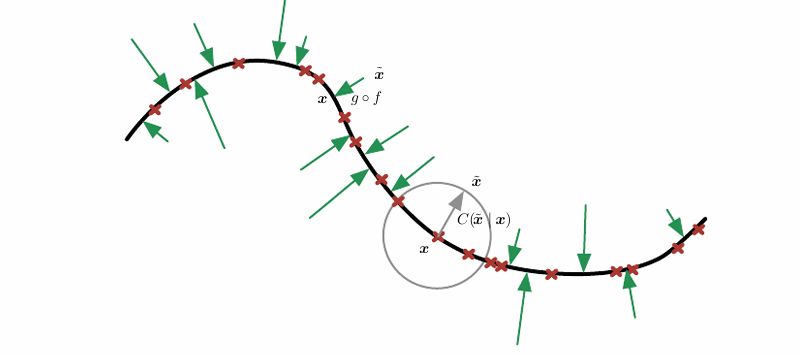

The gray circle is the noise circle that has noise mappings of real input values on the circumference.

Defining the model 

In [11]:
model = DenoisingAutoencoder(input_dim = 4306, latent_dim= 128)
model.to(device)    # shifting the model to CUDA cores

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=4306, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=128, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU()
    (6): Linear(in_features=1024, out_features=4306, bias=True)
  )
)

In [12]:
model.parameters()

<generator object Module.parameters at 0x765729e102e0>

Initializing the ADAM optimizer 

In [13]:
optimizer = optim.Adam(model.parameters(), lr= 1e-3)

loss_fn = nn.MSELoss()      # MSE as the loss functon


In [14]:
X_train_tensor = torch.tensor(X_train, dtype= torch.float32).to(device= device)       # converting the input data to tensor , in out case , each input datapoint is a rank 1 tensor (vector)
y_train_tensor = torch.tensor(y_train, dtype= torch.float32).to(device= device)

X_val_tensor = torch.tensor(X_val, dtype= torch.float32).to(device= device)
y_val_tensor = torch.tensor(y_val, dtype= torch.float32).to(device= device)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

dataset = TensorDataset(X_train_tensor,y_train_tensor)

Creating a joint pair and wrapping the dataset to enable mini-batch training : 

In [15]:
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)    
val_loader   = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32)
test_loader  = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32)

Training loop and optimizing model parameters using backpropagation and ADAM :

In [16]:
loss_list = []
validation_list = []
for epoch in range(1,1001):
    model.train()           # setting the model to training mode
    running_loss = 0      # initializing a running loss for each epoch


    for x_batch,y_batch in train_loader:          # running loop for different batches in each epoch
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        # noisy_input = add_noise(x_batch)           # adding noise to the input batch
        output = model(x_batch)

        loss = loss_fn(output, y_batch)     # calculating the loss function for each batch in an epoch 

        optimizer.zero_grad()       # clears the gradients from previous batch
        loss.backward()         # computes the gradient of the loss function with respect to the parameter/s we want to optimize
        optimizer.step()       # take a small step towards the better value of the parameter

        running_loss += loss        # summing up total loss of all the batches

    print(f"Epoch number : {epoch}, loss = {running_loss}")

    if running_loss < 0.02:     # setting up a threshold for epochs (early stopping)
        break

    model.eval()           # putting the model in validation mode
    val_loss = 0.0          # initializing the validation loss

    with torch.no_grad():       # no backward propagation
        for x_val_batch, y_val_batch in val_loader:

            x_val_batch = x_val_batch.to(device)    # shifting from cpu to CUDA
            y_val_batch = y_val_batch.to(device)

            # noisy_val_input = add_noise(x_val_batch)
            output = model(x_val_batch)

            loss = loss_fn(output, y_val_batch)

            val_loss += loss
        
    print(f"Epoch number : {epoch}, val_loss = {val_loss}")

    loss_list.append(running_loss)
    validation_list.append(val_loss)

Epoch number : 1, loss = 8.838723182678223
Epoch number : 1, val_loss = 2.908440351486206
Epoch number : 2, loss = 3.2321600914001465
Epoch number : 2, val_loss = 2.129929780960083
Epoch number : 3, loss = 2.862238883972168
Epoch number : 3, val_loss = 1.985091209411621
Epoch number : 4, loss = 2.754635810852051
Epoch number : 4, val_loss = 1.8918119668960571
Epoch number : 5, loss = 1.933060646057129
Epoch number : 5, val_loss = 0.8204279541969299
Epoch number : 6, loss = 0.9776751399040222
Epoch number : 6, val_loss = 0.5688605308532715
Epoch number : 7, loss = 0.7836307883262634
Epoch number : 7, val_loss = 0.44144487380981445
Epoch number : 8, loss = 0.6834045052528381
Epoch number : 8, val_loss = 0.4991351366043091
Epoch number : 9, loss = 1.1688964366912842
Epoch number : 9, val_loss = 0.6137125492095947
Epoch number : 10, loss = 0.9409800171852112
Epoch number : 10, val_loss = 0.5595396757125854
Epoch number : 11, loss = 0.820504903793335
Epoch number : 11, val_loss = 0.53871774

Plotting the learning curve for training :

In [17]:
learning_list = []
for i in range(len(loss_list)):
    learning_list.append(loss_list[i].item())

val_list = []

for i in range(len(validation_list)):
    val_list.append(validation_list[i].item())

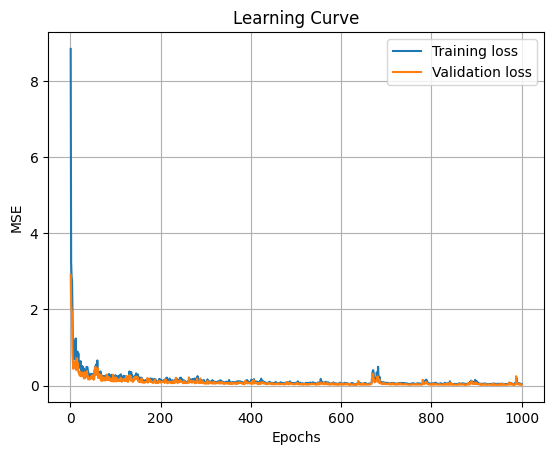

In [18]:
sns.lineplot(x = np.linspace(1,len(learning_list), len(learning_list)), y = learning_list, label = "Training loss")
sns.lineplot(x = np.linspace(1, len(val_list), len(val_list)), y = val_list, label = "Validation loss")
plt.title("Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.grid()

Learning curve for given hyperparameters 

#### Testing the model by fitting it on an input test set :

In [19]:

model.eval()

with torch.no_grad():
    output = model(X_test_tensor)
output

tensor([[0.5643, 0.6510, 0.6638,  ..., 0.6234, 0.6197, 0.6020],
        [2.2252, 2.4110, 2.3904,  ..., 0.3889, 0.3854, 0.3823],
        [0.2022, 0.2371, 0.2385,  ..., 0.7580, 0.7292, 0.7009],
        ...,
        [2.3589, 2.9381, 2.9617,  ..., 0.3627, 0.3643, 0.3583],
        [0.6766, 0.7648, 0.7730,  ..., 0.5939, 0.5958, 0.5880],
        [0.8791, 0.9281, 0.9601,  ..., 0.4258, 0.4269, 0.4201]],
       device='cuda:0')

In [20]:
print(len(output))

425


In [21]:
print(y_test)

[[0.53888705 0.60215445 0.63265395 ... 0.60852682 0.60544576 0.60296546]
 [2.19964031 2.16612994 2.17489859 ... 0.36966142 0.37023875 0.36978689]
 [0.20611021 0.22203613 0.22817872 ... 0.78800541 0.77499684 0.77564789]
 ...
 [2.49479121 2.48518648 2.49914906 ... 0.36419602 0.3648183  0.36520708]
 [0.68171726 0.76241344 0.77895495 ... 0.5677855  0.56857941 0.56949851]
 [0.93837525 0.92078381 0.92622865 ... 0.41745536 0.41863806 0.42012673]]


In [22]:
decoded_flux = output.cpu().numpy()


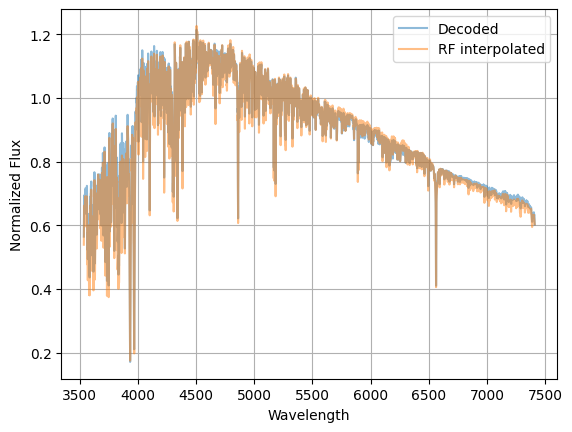

In [23]:
plt.plot(final_wave,decoded_flux[0], label = "Decoded", alpha = 0.5)
plt.plot(final_wave,y_test[0], alpha = 0.5, label = "RF interpolated")
plt.grid()
plt.xlabel("Wavelength")
plt.ylabel("Normalized Flux")
plt.legend()

Reconstruction error (MSE) for the DAE : 

In [24]:
recon_mse = np.mean((decoded_flux - y_test)**2)
recon_mse

np.float64(0.0039491524126866046)